In [15]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from dataloader import RealisticScoreDataset

import torch as th
import numpy as np

real_data_paths = ['/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/real_images/ffhq_256/train/']
gen_data_paths = [
    '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot1_srcC/', 
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot1_maxC/',
    '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_srcC/', 
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_maxC/',
]

train_dataset = RealisticScoreDataset(real_data_paths, gen_data_paths, num_subjects_real=10000, num_subjects_gen=1000, frames_per_subject=5)
train_dataloader = th.utils.data.DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True, num_workers=4)
train_batch = next(iter(train_dataloader))
print(train_batch['latent'].shape)

train_latent = train_batch['latent'].cpu().numpy()
train_labels = train_batch['label'].cpu().numpy()


reg = LinearRegression().fit(train_latent, train_labels)
# Accuracy on train set
out = reg.predict(train_latent)
preds = (out > 0.5).astype(np.float32)
print("[#] Train accuracy: ", (preds == train_labels).mean())
print("[#] Score: ", reg.score(train_latent, train_labels))




Seed set to 47


############### Initializing RealisticScoreDataset ###############
[#] Total real subjects:  10000
[#] Total real frames:  10000
[#] Total generated subjects:  2000
[#] Total generated frames:  10000
[#] Total images (real + gen):  20000
############### Finished initializing RealisticScoreDataset ###############
torch.Size([20000, 512])
[#] Train accuracy:  0.98635
[#] Score:  0.8320985569017085


100%|██████████| 10000/10000 [00:07<00:00, 1383.92it/s]


0.06537750363349915


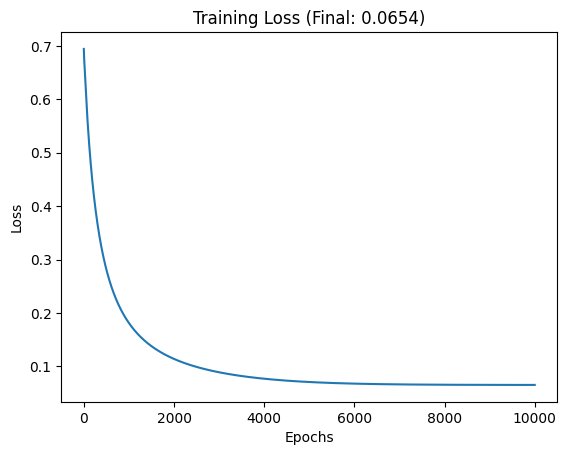

In [16]:
import importlib
import cls
importlib.reload(cls)
import matplotlib.pyplot as plt
device = "cuda:0"
linear_cls = cls.CLS(input_dim=512, lr=1e-3, weight_decay=1e-4, n_epochs=10000, device=device)
linear_cls = linear_cls.to(device)

# Train
linear_cls.fit(train_latent, train_labels)
# Plot loss
print(linear_cls.loss_)
plt.plot(linear_cls.training_loss)    
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f'Training Loss (Final: {linear_cls.loss_:.4f})')
plt.show()


[#] Train accuracy (cls):  0.98075


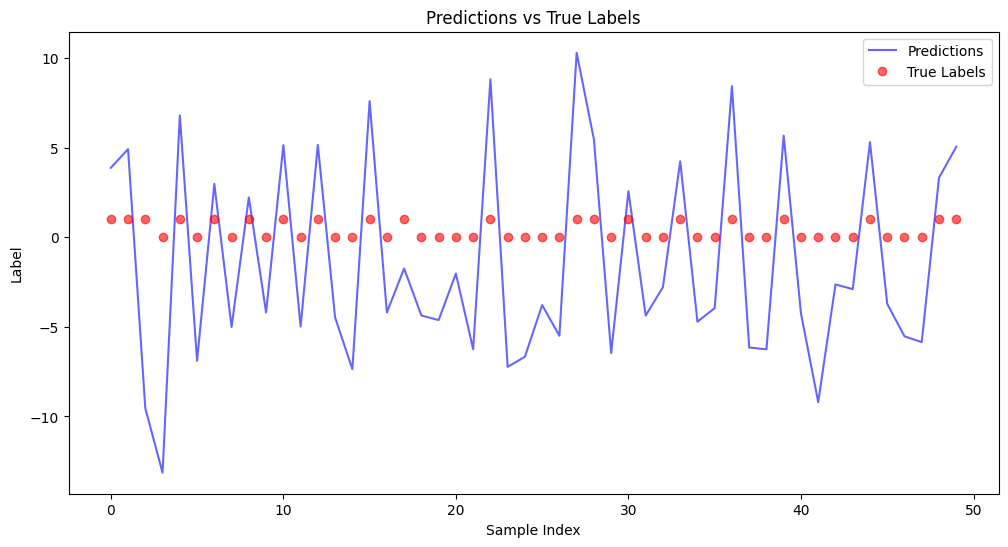

In [ ]:
# Evaluate on train set
cls_proj = train_latent @ linear_cls.coef_.T
train_pred = (cls_proj > 0).astype(np.float32).squeeze()

print("[#] Train accuracy (cls): ", (train_pred == train_labels).mean())

# Plot preds (x axis is showing labels text)
n = 50
plt.figure(figsize=(12, 6))
plt.plot(range(len(train_labels[:n])), cls_proj[:n], c='blue', label='Predictions', alpha=0.6)
plt.plot(range(len(train_labels[:n])), train_labels[:n], 'ro', label='True Labels', alpha=0.6)
plt.xlabel('Sample Index')
plt.ylabel('Label')
plt.title('Predictions vs True Labels (Train Set)')
plt.legend()
plt.show()

In [26]:
test_real_data_paths = [
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/real_images/ffhq_256/valid/'
]
test_gen_data_paths = [
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot1_srcC/', 
    '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot1_maxC/',
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_srcC/', 
    '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_maxC/',
]
test_dataset = RealisticScoreDataset(test_real_data_paths, test_gen_data_paths, num_subjects_real=5000, num_subjects_gen=500, frames_per_subject=5, seed=1234)
test_dataloader = th.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset))
test_batch = next(iter(test_dataloader))
print(test_batch['latent'].shape)

test_latent = test_batch['latent'].cpu().numpy()
test_labels = test_batch['label'].cpu().numpy()
print(test_labels)

out = reg.predict(test_latent)
dotout =  test_latent @ reg.coef_.T # + reg.intercept_ # should be identical to out if we add intercept
assert np.allclose(out, dotout + reg.intercept_)
print(out)
print(dotout)
preds = (out > 0.8).astype(np.float32)
print("[#] Test accuracy: ", (preds == test_labels).mean())
print("[#] Score: ", reg.score(test_latent, test_labels))

Seed set to 1234


############### Initializing RealisticScoreDataset ###############
[#] Total real subjects:  0
[#] Total real frames:  0
[#] Total generated subjects:  1000
[#] Total generated frames:  5000
[#] Total images (real + gen):  5000
############### Finished initializing RealisticScoreDataset ###############
torch.Size([5000, 512])
[0 0 0 ... 0 0 0]
[ 0.09671593 -0.0074873  -0.1515131  ...  0.12244797  0.19935131
  0.23545933]
[-5.3513956 -5.455599  -5.5996246 ... -5.3256636 -5.24876   -5.212652 ]
[#] Test accuracy:  0.9998
[#] Score:  0.0


[#] Test accuracy (cls):  0.9976


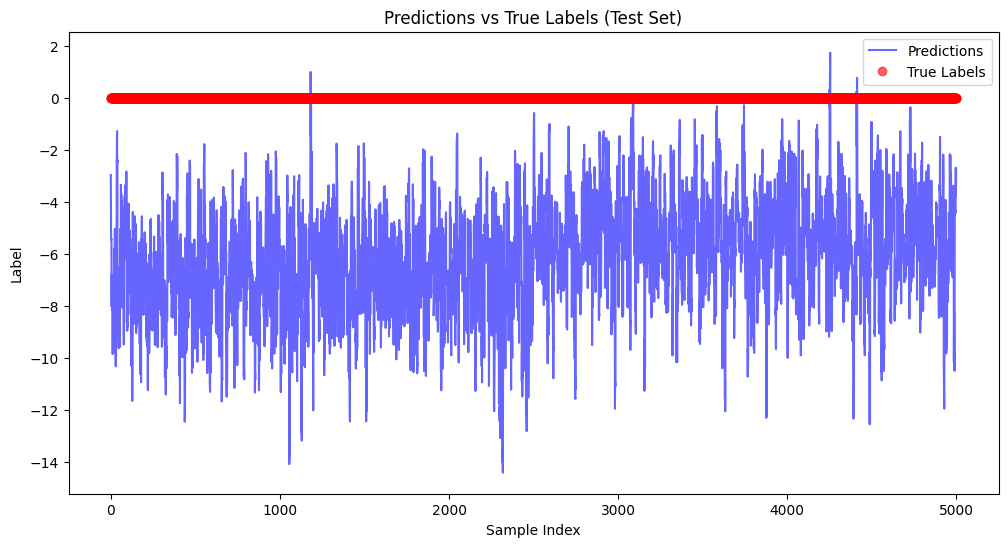

5000


<Figure size 2000x1000 with 0 Axes>

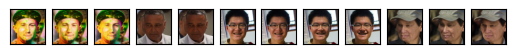

In [ ]:
# Evaluate on test set
cls_proj = test_latent @ linear_cls.coef_.T
test_pred = (cls_proj > 0).astype(np.float32).squeeze()

print("[#] Test accuracy (cls): ", (test_pred == test_labels).mean())

# Plot preds (x axis is showing labels text)
n = 5000
plt.figure(figsize=(12, 6))
plt.plot(range(len(test_labels[:n])), cls_proj[:n], c='blue', label='Predictions', alpha=0.6)
plt.plot(range(len(test_labels[:n])), test_labels[:n], 'ro', label='True Labels', alpha=0.6)
plt.xlabel('Sample Index')
plt.ylabel('Label')
plt.title('Predictions vs True Labels (Test Set)')
plt.legend()
plt.show()

# Get where cls_proj = 1
cls_proj_1_indices = np.where(cls_proj > 0)[0]
looks_realistic = [test_batch['image_path'][x] for x in cls_proj_1_indices]
print(len(test_batch['image_path']))
# Show images as a grid
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torchvision.transforms.functional as F


plt.rcParams["savefig.bbox"] = 'tight'


def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    # Set figure size
    fig.set_size_inches(np.array(fig.get_size_inches()) * len(imgs))
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

show([th.tensor(np.array(Image.open(test_batch['image_path'][x]))).permute(2, 0, 1) for x in cls_proj_1_indices[:]])